X = data[['RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'Butterflyfish',
          'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse', 'BumpheadParrotfish',
           'Parrotfish', 'MoralEel', 'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L',
           'Total_fish', 'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin',
           'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS', 'GiantClam_S', 'GiantClam_M',
           'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL', 'Total_invert', 'Damage_boat', 'Damage_dynamite',
           'Damage_other', 'Trash_fishery', 'Trash_general','year', 'month', 'day']]
y = data['C']

最dope特徵

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

# 分割特徵和目標，包括時間特徵
X = data[[ 'RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'COTS', 'year', 'month', 'day']]
y = data['C']

相關係數

In [ ]:
X = data[[ 'RC', 'NIA', 'SD', 'Trash_general', 'GiantClam_S', 'SI', 'GiantClam_M', 'GiantClam_XS',  'year', 'month', 'day']]
y = data['C']

決策樹的特徵重要性

In [ ]:
X = data[['RC','NIA','SI','SD','RB','SP','OT','Butterflyfish','Total_fish','Trash_general','Total_invert','Diadema','RKC','Trash_fishery','Parrotfish','Grouper_XS','MoralEel','year', 'month', 'day']]
y = data['C']

梯度提升樹的特徵重要性

In [ ]:
X = data[['RC','NIA','SI','SD','RB','OT','SP','RKC','Total_fish','Butterflyfish','Trash_general','MoralEel','CollectorUrchin','GiantClam_M','Diadema','Haemulidae','GiantClam_S','BandedCoralShrimp','Total_invert','Diadema','GiantClam_XS','Damage_other','Parrotfish','Snapper','year', 'month', 'day']]
y = data['C']

# 預測模型

梯度回歸

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump

# 读取数据集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 将 "Date" 列转换为日期时间对象
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和时间特征
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

X = data[['RC','NIA','SI','SD','RB','OT','SP','RKC','Total_fish','year', 'month', 'day']]
y = data['C']

# 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建梯度提升随机森林回归模型
gb_rf_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42, subsample=0.1)

# 训练模型
gb_rf_model.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = gb_rf_model.predict(X_test)

# 计算均方根误差（RMSE）
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# 计算决定系数（R平方）
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

print(y_pred)
# 存储模型
dump(gb_rf_model, 'gb_rf_regressor_model.joblib')


<ipython-input-43-1e0737f43894>:19: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-43-1e0737f43894>:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


Root Mean Squared Error (RMSE): 0.03345033240803867
R^2 Score: 0.9721979522154525
[0.10597215 0.22592619 0.65222792 0.42479001 0.29147595 0.51987835
 0.48556761 0.4279079  0.09483513 0.05882083 0.28955794 0.75788954
 0.21544914 0.28462182 0.32276027 0.65001763 0.49918988 0.36217666
 0.17065144 0.41653246 0.75445138 0.63050191 0.62622255 0.11547063
 0.68958601 0.85707863 0.3770398  0.50227489 0.32025289 0.5570297
 0.4818291  0.19150267 0.43145827 0.36936377 0.50240997 0.39811461
 0.24417928 0.42646913 0.24261391 0.31520457 0.5854274  0.70124872
 0.48924909 0.35334405 0.32506362 0.25751736 0.62021449 0.34179239
 0.31063644 0.41925343 0.55028372 0.7067031  0.24737099 0.13645957
 0.73028299 0.60297939 0.26500958 0.62851675 0.73395384 0.22234508
 0.26556389 0.35262044 0.23417407 0.49554303 0.04429036 0.4106086
 0.64454805 0.19789525 0.32888686 0.16191595 0.6245074  0.50315487
 0.48363502 0.25084746 0.6592733  0.3184776  0.73028299 0.43720813
 0.60787799 0.42463354 0.50569066 0.69591423 0.62

['gb_rf_regressor_model.joblib']

隨機森林

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_error, r2_score
from joblib import dump

# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RC','NIA','SI','SD','RB','OT','SP','RKC','Total_fish','year', 'month', 'day']]
y = data['C']
# 训练集和测试集的分割，通常80%训练，20%测试
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 創建決策樹回歸模型
regressor = RandomForestRegressor(random_state=42)

# 訓練模型
regressor.fit(X_train, y_train)

# 預測
y_pred = regressor.predict(X_test)

# 計算均方根誤差（RMSE）
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"均方根誤差 (RMSE): {rmse}")

# 計算決定係數（R平方）
r2 = r2_score(y_test, y_pred)
print(f"R^2 分數: {r2}")

# 存储模型
dump(regressor, 'regressor_model.joblib')



<ipython-input-44-3219abbca69c>:20: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-44-3219abbca69c>:20: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


均方根誤差 (RMSE): 0.05033255224417081
R^2 分數: 0.9370531769915


['regressor_model.joblib']

決策樹

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump

# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RC','NIA','SI','SD','RB','year', 'month', 'day']]
y = data['C']

# 將數據拆分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 創建並訓練決策樹回歸模型
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# 在測試集上進行預測
y_pred = tree_reg.predict(X_test)

# 評估模型性能，包括均方根誤差和R平方值
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'均方根誤差：{rmse}')
print(f'R平方值：{r2}')

dump(tree_reg, 'regressor_model3.joblib')

均方根誤差：0.09169110133767687
R平方值：0.7911039210546161


<ipython-input-31-3fded78e311e>:19: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-31-3fded78e311e>:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


['regressor_model3.joblib']

前饋神經網路

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense
from joblib import dump

# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RC','NIA','SI','SD','RB','OT','SP','RKC','year', 'month', 'day']]
y = data['C']

# 訓練集和測試集的分割，通常80%訓練，20%測試
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特徵標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 初始化神經網路模型
model = Sequential()

# 添加隱藏層，這裡使用了兩個具有50個神經元的隱藏層，也可以嘗試調整層數和神經元數量
model.add(Dense(64, input_dim=11, activation='relu'))
model.add(Dense(32, activation='relu'))

# 添加輸出層，這裡是單個神經元的輸出，因為預測 "HC" 是一個連續值
model.add(Dense(1, activation='linear'))

# 編譯模型
model.compile(loss='mean_squared_error', optimizer='adam')

# 訓練模型
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=1)

# 在測試集上進行預測
y_pred = model.predict(X_test_scaled)

# 計算均方根誤差（RMSE）
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"均方根誤差 (RMSE): {rmse}")

# 計算決定係數（R平方）
r2 = r2_score(y_test, y_pred)
print(f"R^2 分數: {r2}")

# 存储模型
dump(model, 'regressor_model2.joblib')

<ipython-input-75-6468d05278d5>:21: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-75-6468d05278d5>:21: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


Epoch 1/100
35/35 [==============================] - 1s 4ms/step - loss: 0.1118
Epoch 2/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0237
Epoch 3/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0129
Epoch 4/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0087
Epoch 5/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0065
Epoch 6/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0049
Epoch 7/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0040
Epoch 8/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0034
Epoch 9/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0030
Epoch 10/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0025
Epoch 11/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0022
Epoch 12/100
35/35 [==============================] - 0s 3ms/step - loss: 0.0020
Epoch 13/100
35/35 [=================

['regressor_model2.joblib']

# 十次交叉驗證

K-fold

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score
import joblib  # 如果您使用的是Scikit-Learn版本0.20或更早版本，可以使用joblib而不是joblib模塊

# 載入您已經訓練好的模型
model = joblib.load('/content/gb_rf_regressor_model.joblib')  # 請替換成您模型的實際文件名


# 初始化十折交叉驗證
kf = KFold(n_splits=10, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # 使用模型進行預測
    y_pred = model.predict(X_test)

    # 計算RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append(rmse)

    # 計算R平方
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

# 輸出每次交叉驗證的RMSE和R平方
for i in range(10):
    print(f"Fold {i + 1} - RMSE: {rmse_scores[i]:.4f}, R^2: {r2_scores[i]:.4f}")

# 計算平均RMSE和平均R平方
average_rmse = np.mean(rmse_scores)
average_r2 = np.mean(r2_scores)

print(f"Average RMSE: {average_rmse:.4f}")
print(f"Average R^2: {average_r2:.4f}")



Fold 1 - RMSE: 0.1279, R^2: 0.5609
Fold 2 - RMSE: 0.1392, R^2: 0.5518
Fold 3 - RMSE: 0.1249, R^2: 0.6337
Fold 4 - RMSE: 0.1259, R^2: 0.6852
Fold 5 - RMSE: 0.1211, R^2: 0.6415
Fold 6 - RMSE: 0.1218, R^2: 0.6893
Fold 7 - RMSE: 0.1322, R^2: 0.6018
Fold 8 - RMSE: 0.1325, R^2: 0.6244
Fold 9 - RMSE: 0.1275, R^2: 0.6732
Fold 10 - RMSE: 0.1357, R^2: 0.5534
Average RMSE: 0.1289
Average R^2: 0.6215


# 特徵篩選

相關係數

In [ ]:
import pandas as pd
import numpy as np

# 读取数据集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 将 "Date" 列转换为日期时间对象
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和时间特征
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特征和目标，包括时间特征
X = data[['RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'Butterflyfish', 'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse', 'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish', 'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin', 'SeaCucumber', 'COTS', 'Triton', 'Lobster',  'GiantClam_XS', 'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL', 'Total_invert', 'Damage_boat', 'Damage_dynamite', 'Damage_other', 'Trash_fishery', 'Trash_general','year', 'month', 'day']]
y = data['C']

# 计算每个特征与目标的相关系数并按大小排序
feature_correlations = X.corrwith(y).sort_values(ascending=False)

# 打印特征与目标的相关系数
print(feature_correlations)


GiantClam_S           0.129580
GiantClam_M           0.120087
GiantClam_XS          0.106672
GiantClam_L           0.093776
SP                    0.091842
Total_fish            0.090003
Parrotfish            0.087569
Butterflyfish         0.082223
Snapper               0.064847
GiantClam_XXL         0.063912
COTS                  0.060547
Triton                0.043883
GiantClam_XL          0.040678
PencilUrchin          0.029522
RKC                   0.024029
Haemulidae            0.017887
Damage_other          0.000297
Grouper_L            -0.005840
Grouper_S            -0.008160
SeaCucumber          -0.009090
Grouper_M            -0.010237
BarramundiCod        -0.010638
Total_invert         -0.015000
MoralEel             -0.020887
Diadema              -0.020936
year                 -0.022577
Damage_boat          -0.023721
Trash_fishery        -0.045475
OT                   -0.050473
BandedCoralShrimp    -0.057030
Grouper_XS           -0.079521
CollectorUrchin      -0.087237
day     

<ipython-input-18-a26e9b908815>:15: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-18-a26e9b908815>:15: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


<ipython-input-19-f45ce25d880c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlations = data.corr()['C']


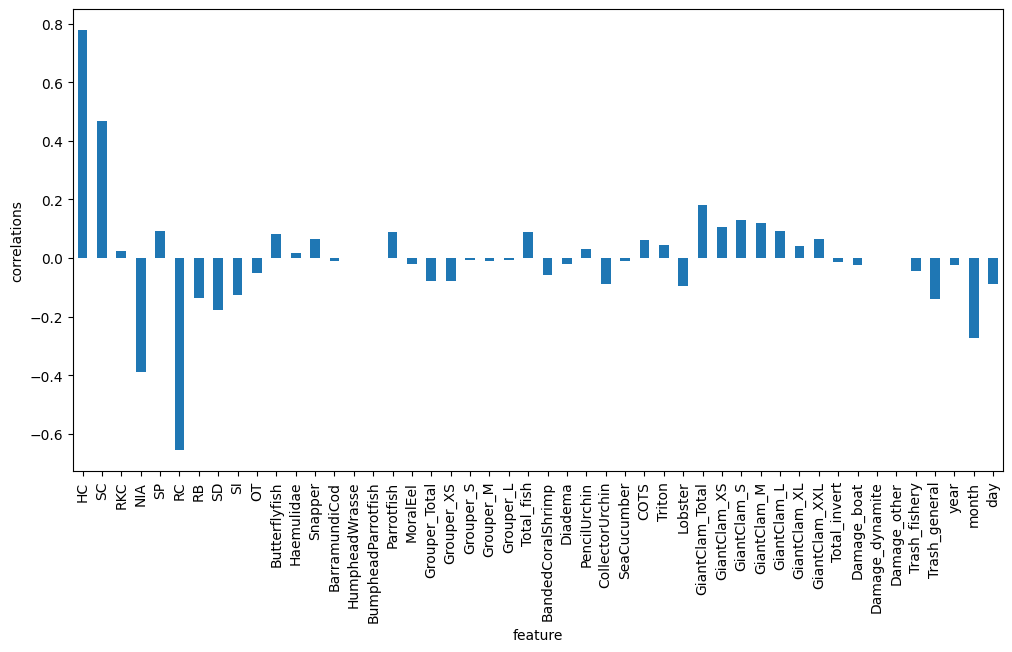

In [ ]:
# 計算特徵和目標的相關係數
correlations = data.corr()['C']

# 繪製相關係數的長條圖
plt.figure(figsize=(12, 6))
correlations.drop('C').plot(kind='bar')
plt.xlabel('feature')
plt.ylabel('correlations')
plt.show()

特徵重要性

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump

# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'Butterflyfish', 'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse', 'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish', 'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin', 'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS', 'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL', 'Total_invert', 'Damage_boat', 'Damage_dynamite', 'Damage_other', 'Trash_fishery', 'Trash_general','year', 'month', 'day']]
y = data['C']

# 將數據拆分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 創建並訓練決策樹回歸模型
tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(X_train, y_train)

# 在測試集上進行預測
y_pred = tree_reg.predict(X_test)

# 評估模型性能，包括均方根誤差和R平方值
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'均方根誤差：{rmse}')
print(f'R平方值：{r2}')

# 創建一個包含特徵名稱和對應重要性的DataFrame
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# 按照重要性由大到小排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 打印排序後的結果
print(feature_importance_df)

# 將模型保存為.joblib文件
dump(tree_reg, 'regressor_model3.joblib')

# 繪製相關係數的長條圖
plt.figure(figsize=(12, 6))
correlations.drop('C').plot(kind='bar')
plt.xlabel('feature')
plt.ylabel('correlations')
plt.show()


均方根誤差：3.3554908999852033
R平方值：0.968064074595875
               Feature    Importance
3                   RC  9.553814e-01
1                  NIA  1.253166e-02
22             Diadema  6.638860e-03
35        Total_invert  5.640222e-03
40       Trash_general  2.028433e-03
4                   RB  1.735378e-03
0                  RKC  1.671283e-03
8        Butterflyfish  1.659016e-03
30         GiantClam_S  1.463505e-03
38        Damage_other  1.347155e-03
16          Grouper_XS  1.136277e-03
43                 day  1.013083e-03
20          Total_fish  9.627344e-04
5                   SD  8.641203e-04
41                year  7.271712e-04
17           Grouper_S  6.415557e-04
42               month  5.992224e-04
15            MoralEel  5.718010e-04
29        GiantClam_XS  5.375995e-04
14          Parrotfish  4.925153e-04
21   BandedCoralShrimp  4.496497e-04
7                   OT  4.456793e-04
39       Trash_fishery  3.519229e-04
31         GiantClam_M  2.726416e-04
6                   SI  2.3

<ipython-input-89-7680a7274871>:19: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-89-7680a7274871>:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


NameError: ignored

<Figure size 1200x600 with 0 Axes>

<ipython-input-20-5a3528f57ceb>:20: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-20-5a3528f57ceb>:20: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


均方根誤差 (RMSE): 0.05296651830101632
R^2 分數: 0.930292619698281
               Feature    Importance
3                   RC  5.118101e-01
1                  NIA  2.752892e-01
6                   SI  5.515943e-02
5                   SD  4.816709e-02
4                   RB  4.199118e-02
2                   SP  8.826194e-03
7                   OT  6.927862e-03
41                year  6.227840e-03
8        Butterflyfish  5.833395e-03
43                 day  5.735421e-03
20          Total_fish  5.425711e-03
42               month  4.642288e-03
40       Trash_general  3.425907e-03
35        Total_invert  3.322313e-03
22             Diadema  2.633336e-03
0                  RKC  2.074112e-03
39       Trash_fishery  1.911464e-03
14          Parrotfish  1.729953e-03
16          Grouper_XS  1.363053e-03
15            MoralEel  1.035047e-03
21   BandedCoralShrimp  9.136192e-04
30         GiantClam_S  8.535595e-04
10             Snapper  8.050399e-04
9           Haemulidae  7.662117e-04
29        Giant

<Figure size 640x480 with 0 Axes>

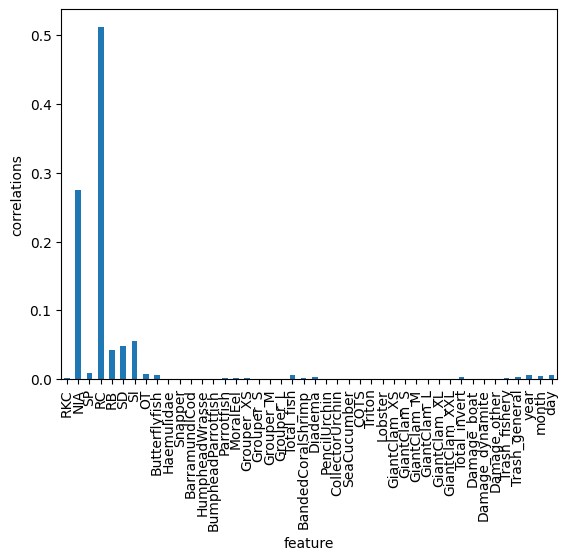

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_error, r2_score
from joblib import dump

# 讀取數據集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 將 "Date" 欄位轉換為日期時間物件
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和時間特徵
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'Butterflyfish', 'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse', 'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish', 'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin', 'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS', 'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL', 'Total_invert', 'Damage_boat', 'Damage_dynamite', 'Damage_other', 'Trash_fishery', 'Trash_general','year', 'month', 'day']]
y = data['C']

# 训练集和测试集的分割，通常80%训练，20%测试
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 創建決策樹回歸模型
regressor = RandomForestRegressor(random_state=42)

# 訓練模型
regressor.fit(X_train, y_train)

# 預測
y_pred = regressor.predict(X_test)

# 計算均方根誤差（RMSE）
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"均方根誤差 (RMSE): {rmse}")

# 計算決定係數（R平方）
r2 = r2_score(y_test, y_pred)
print(f"R^2 分數: {r2}")

# 存储模型
dump(regressor, 'regressor_model.joblib')

# 獲取特徵重要性
feature_importance = regressor.feature_importances_

# 創建一個包含特徵名稱和對應重要性的DataFrame
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# 按照重要性由大到小排序
feature_importance_df_1 = feature_importance_df.sort_values(by='Importance', ascending=False)

# 打印排序後的結果
print(feature_importance_df_1)

# 繪製相關係數的長條圖
plt.figure()
feature_importance_df.plot(x='Feature', y='Importance', kind='bar', legend=False)
plt.xlabel('feature')
plt.ylabel('correlations')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump

# 读取数据集
data = pd.read_csv('/content/ReefCheckTaiwan_2009_2020_data_new - ReefCheckTaiwan_2009_2020_data.csv')

# 将 "Date" 列转换为日期时间对象
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# 添加日期和时间特征
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day

data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值

# 分割特徵和目標，包括時間特徵
X = data[['RKC', 'NIA', 'SP', 'RC', 'RB', 'SD', 'SI', 'OT', 'Butterflyfish', 'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse', 'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish', 'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin', 'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS', 'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL', 'Total_invert', 'Damage_boat', 'Damage_dynamite', 'Damage_other', 'Trash_fishery', 'Trash_general','year', 'month', 'day']]
y = data['C']

# 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建梯度提升随机森林回归模型
gb_rf_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42, subsample=0.1)

# 训练模型
gb_rf_model.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = gb_rf_model.predict(X_test)

# 计算均方根误差（RMSE）
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# 计算决定系数（R平方）
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

# 獲取特徵重要性
feature_importance = gb_rf_model.feature_importances_

# 創建一個包含特徵名稱和對應重要性的DataFrame
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# 按照重要性由大到小排序
feature_importance_df_1 = feature_importance_df.sort_values(by='Importance', ascending=False)

# 打印排序後的結果
print(feature_importance_df_1)

# 繪製相關係數的長條圖
plt.figure()
feature_importance_df.plot(x='Feature', y='Importance', kind='bar', legend=False)
plt.xlabel('feature')
plt.ylabel('correlations')
plt.show()

# 存储模型
dump(gb_rf_model, 'gb_rf_regressor_model.joblib')


<ipython-input-1-36083d77f698>:19: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值
<ipython-input-1-36083d77f698>:19: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)  # 使用平均值填充缺失值


Root Mean Squared Error (RMSE): 0.03654157366943379
R^2 Score: 0.9668219847456773
               Feature    Importance
3                   RC  4.327007e-01
1                  NIA  2.472428e-01
6                   SI  7.903936e-02
5                   SD  6.395268e-02
4                   RB  5.712668e-02
7                   OT  1.561173e-02
42               month  1.550291e-02
2                   SP  1.443298e-02
0                  RKC  1.231813e-02
41                year  1.138069e-02
20          Total_fish  5.401958e-03
8        Butterflyfish  5.274814e-03
43                 day  4.783851e-03
40       Trash_general  4.181152e-03
15            MoralEel  3.969141e-03
24     CollectorUrchin  3.895003e-03
31         GiantClam_M  3.454389e-03
22             Diadema  2.748506e-03
9           Haemulidae  2.415938e-03
30         GiantClam_S  2.331322e-03
21   BandedCoralShrimp  1.977485e-03
35        Total_invert  1.970653e-03
29        GiantClam_XS  1.906998e-03
38        Damage_other  1.4618

NameError: ignored

反向淘汰法